# Système de recommandation agricole - Feature engineering
- L'objectif ici va d'être de réaliser l'enrichissement de notre nouveau df avec les varibales clés de crop_yield
- Ensuite on va passer au feature engineering à proprement parlé

In [2]:
# Imports de base
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

## On charge nos données

In [2]:
# Fichier yield consolidé
data_yield_conso = pd.read_csv("../data/processed/yield_df_final.csv")
crop_yield = pd.read_csv("../data/raw/crop_yield.csv")

### Vérification des cultures par fichier

In [3]:
# Type de culture unique par fichier
print(f"Type de culture dans yield :{data_yield_conso['item'].unique()}\n")
print(f"Type de culture dans crop_yield :{crop_yield['Crop'].unique()}\n")
print("="*20)
# Valeur par type de culture par fichier
print(f"Fichier yield consolidé : {data_yield_conso['item'].value_counts()}\n")
print(f"Fichier crop_yield : {crop_yield['Crop'].value_counts()}")

Type de culture dans yield :<StringArray>
[               'Maize',             'Potatoes',          'Rice, paddy',
                'Wheat',              'Sorghum',             'Soybeans',
              'Cassava',                 'Yams',       'Sweet potatoes',
 'Plantains and others']
Length: 10, dtype: str

Type de culture dans crop_yield :<StringArray>
['Cotton', 'Rice', 'Barley', 'Soybean', 'Wheat', 'Maize']
Length: 6, dtype: str

Fichier yield consolidé : item
Maize                   4426
Potatoes                4163
Wheat                   3289
Rice, paddy             3171
Sweet potatoes          3111
Sorghum                 2826
Cassava                 2771
Soybeans                2428
Yams                    1615
Plantains and others    1351
Name: count, dtype: int64

Fichier crop_yield : Crop
Maize      166824
Rice       166792
Barley     166777
Wheat      166673
Cotton     166585
Soybean    166349
Name: count, dtype: int64


On note une différence entre les fichiers sur les types de culture :

- Nous devons effectuer un mapping pour faire correspondre les bonnes cultures
- **On note également qu'il y a 10 cultures dans le fchier consolidé et seulement 6 dans le dataset synthétique. Il faudrait bien avoir ça en tête lors de l'imputation.**
- Les éléments suivants n'auront pas d'équivalents directs :
    - Potatoes
    - Sweet potatoes
    - Sorghum
    - Cassava
    - Yams
    - Plantains and others
- L'idée va être de réunir un maximum d'informations depuis la relation culture des deux datasets et pour les relations directes manquantes, nous allons le faire par pays dans le fichier consolidé puis par groupe climatique
- On voit également que la dataset "synthétique" propose un équilibre quasi parfait entre type de culture

### Analyse des variables similaires

In [4]:
print(f"Fichier yield consolidé : \n{data_yield_conso[["avg_temp","rainfall_mm"]].describe()}\n")
print(f"Fichier crop_yield : \n{crop_yield[["Temperature_Celsius","Rainfall_mm"]].describe()}\n")

Fichier yield consolidé : 
           avg_temp   rainfall_mm
count  29151.000000  29151.000000
mean      20.286183   1227.017289
std        5.911377    746.155030
min       -3.370000     51.000000
25%       17.330000    637.000000
50%       21.340000   1146.000000
75%       24.930000   1705.000000
max       30.420000   3240.000000

Fichier crop_yield : 
       Temperature_Celsius     Rainfall_mm
count       1000000.000000  1000000.000000
mean             27.504965      549.981901
std               7.220608      259.851320
min              15.000034      100.000896
25%              21.254502      324.891090
50%              27.507365      550.124061
75%              33.753267      774.738520
max              39.999997      999.998098



Les statistiques ne donnent pas les mêmes amplitudes par variables :
- Du côté du fichier consolidé sur la temp on a pas la distinction des pays avec climat froid, le minimum est à 15 degrés alors qu'il est à -3 pour le fichier consolidé, on note un écart pour le maximum également.
- Ce n'est pas parfait pour ajouter des données mais l'idée est de rajouter des proxys, donc des mesures approximatives afin d'aider un modèle à trouver des patterns.

### Normalisation des noms dans notre fichier consolidé

In [5]:
# Utilisation de replace pour changer les noms
data_yield_conso['item'] = data_yield_conso['item'].replace({
    'Rice, paddy': 'Rice',
    'Soybeans': 'Soybean',
    'Maize': 'Maize',
    'Wheat': 'Wheat',
    'Barley': 'Barley'
})
data_yield_conso['item'].unique()

<StringArray>
[               'Maize',             'Potatoes',                 'Rice',
                'Wheat',              'Sorghum',              'Soybean',
              'Cassava',                 'Yams',       'Sweet potatoes',
 'Plantains and others']
Length: 10, dtype: str

## Enrichissement du fichier consolidé

Il n'y a de relation directe entre notre premier dataset (celui pour l'ACP) et les autres datasets.
- Le premier fichier est par grande région et culture
- Le deuxième fichier est par pays, par année puis par culture
- Le rapprochement des données serait très bancal.

**Mais nous avons identifié des variables proxy qui pourraient enrichir notre dataset :**
- Irrigation_Used
- Fertilizer_Used
- Weather_Condition
- Soil_Type

Le fichier crop_yield semble être un fichier synthétique :
- Pas de corrélation entre les variables explicatives
- Répartition à quasi 50/50 des valeurs pour chaque variables 

Plusieurs méthodes d'enrichissement ont été effectué :
- Modèle de régression logistique afin de prédire les différentes variables sur le nouveau fichier
    - Variables explicative : précipitation et température
    - Après un test, le modèle n'arrive pas à généraliser, les variables explicatives sont indépendantes entre elles Les données sont "plates" (sans corrélations fortes), le modèle de ML essayait de trouver une règle là où il n'y en a pas
    - Par exemple, la balanced_accuracy était à 0,50 pour le fertilisant et l'irrigation

- Méthode de stratification par catégorie afin de faire le rapprochement sur le nouveau fichier en utilisation la valeur la plus fréquente (mode())
    - La mise en place de la stratification était simple (en quartiles)
    - Le problème est l'utilisation de la valeur fréquente. Quand il y a une valeur qui se démarque, cela fonctionne bien. Cependant sur une égalité, le mode choisit aléatoirement
- Méthode de sampling conditionnel afin d'attribuer la distribution de crop_yield par culture/clé climatique puis choix statistique de la valeur avec une fonction random
    - Méthode retenue

### Méthode du sampling conditionnel

- Standardisation des noms des types de culture entre les fichiers
- Autre problématique : nous avons uniquement 4 cultures en communs entre les 2 fichiers

In [6]:
# Avoir de pouvoir reproduire nos éléments
np.random.seed(42)
# Chargement de nos fichiers
yield_df_final = data_yield_conso.copy()
yield_df = yield_df_final.copy()
crop_df = crop_yield.copy()
# Colonnes que l'on veut retrouver
cols = ["Fertilizer_Used", "Irrigation_Used", "Weather_Condition", "Soil_Type"]
# Créer les colonnes manquantes en object, pas en float
for col in cols:
    if col not in yield_df.columns:
        yield_df[col] = pd.Series([None] * len(yield_df), dtype="object")
    else:
        yield_df[col] = yield_df[col].astype("object")

### Création de la clé climatique

In [7]:
# Construire climate_key avec les bornes apprises sur crop_yield
temp_edges = crop_df["Temperature_Celsius"].quantile([0.25, 0.5, 0.75]).tolist()
rain_edges = crop_df["Rainfall_mm"].quantile([0.25, 0.5, 0.75]).tolist()

temp_bins = [-np.inf] + temp_edges + [np.inf]
rain_bins = [-np.inf] + rain_edges + [np.inf]

labels_t = ["T1", "T2", "T3", "T4"]
labels_r = ["R1", "R2", "R3", "R4"]

crop_df["temp_q"] = pd.cut(
    crop_df["Temperature_Celsius"],
    bins=temp_bins,
    labels=labels_t,
    include_lowest=True
)
crop_df["rain_q"] = pd.cut(
    crop_df["Rainfall_mm"],
    bins=rain_bins,
    labels=labels_r,
    include_lowest=True
)
crop_df["climate_key"] = crop_df["temp_q"].astype(str) + "_" + crop_df["rain_q"].astype(str)

yield_df["temp_q"] = pd.cut(
    yield_df["avg_temp"],
    bins=temp_bins,
    labels=labels_t,
    include_lowest=True
)
yield_df["rain_q"] = pd.cut(
    yield_df["rainfall_mm"],
    bins=rain_bins,
    labels=labels_r,
    include_lowest=True
)
yield_df["climate_key"] = yield_df["temp_q"].astype(str) + "_" + yield_df["rain_q"].astype(str)


### Récupération de la distribution des éléments depuis crop_yield

In [8]:
# Distributions depuis crop_yield
dist_ref = {}
dist_crop = {}
dist_global = {}

for col in cols:
    dist_ref[col] = crop_df.groupby(["climate_key", "Crop"])[col].value_counts(normalize=True)
    dist_crop[col] = crop_df.groupby("Crop")[col].value_counts(normalize=True)
    dist_global[col] = crop_df[col].value_counts(normalize=True)

# Fonction de sampling
def sample_value(row, col):
    ck = row["climate_key"]
    crop = row["item"]

    # climate_key + crop
    try:
        dist = dist_ref[col].loc[(ck, crop)]
        return np.random.choice(dist.index.to_list(), p=dist.values)
    except Exception:
        pass

    # crop seul
    try:
        dist = dist_crop[col].loc[crop]
        return np.random.choice(dist.index.to_list(), p=dist.values)
    except Exception:
        pass

    # global
    dist = dist_global[col]
    return np.random.choice(dist.index.to_list(), p=dist.values)

### Imputation des NaN ligne par ligne

In [9]:
# Remplir les NaN ligne par ligne
for col in cols:
    mask = yield_df[col].isna()

    if mask.sum() > 0:
        sampled_values = yield_df.loc[mask].apply(
            lambda row: sample_value(row, col),
            axis=1
        )

        yield_df.loc[mask, col] = sampled_values.astype("object")

# Recast final propre
yield_df["Fertilizer_Used"] = yield_df["Fertilizer_Used"].astype(bool)
yield_df["Irrigation_Used"] = yield_df["Irrigation_Used"].astype(bool)
yield_df["Weather_Condition"] = yield_df["Weather_Condition"].astype(str)
yield_df["Soil_Type"] = yield_df["Soil_Type"].astype(str)

# 8) Vérification
print("NaN restants :")
print(yield_df[cols].isna().sum())

# 9) Nettoyage optionnel
yield_df = yield_df.drop(columns=["temp_q", "rain_q"], errors="ignore")

yield_df_final = yield_df.copy()

NaN restants :
Fertilizer_Used      0
Irrigation_Used      0
Weather_Condition    0
Soil_Type            0
dtype: int64


### Vérification des distributions

In [10]:
# Pour les variables proxy
cols = ['Fertilizer_Used','Irrigation_Used','Weather_Condition','Soil_Type']
for col in cols:
    print(f"\n=== {col} ===")
    print("Source (crop_yield):")
    print(crop_yield[col].value_counts(normalize=True))

    print("\nFinal (yield_df_final):")
    print(yield_df_final[col].value_counts(normalize=True))


=== Fertilizer_Used ===
Source (crop_yield):
Fertilizer_Used
False    0.50006
True     0.49994
Name: proportion, dtype: float64

Final (yield_df_final):
Fertilizer_Used
False    0.501252
True     0.498748
Name: proportion, dtype: float64

=== Irrigation_Used ===
Source (crop_yield):
Irrigation_Used
False    0.500509
True     0.499491
Name: proportion, dtype: float64

Final (yield_df_final):
Irrigation_Used
True     0.503482
False    0.496518
Name: proportion, dtype: float64

=== Weather_Condition ===
Source (crop_yield):
Weather_Condition
Sunny     0.333790
Rainy     0.333561
Cloudy    0.332649
Name: proportion, dtype: float64

Final (yield_df_final):
Weather_Condition
Cloudy    0.335666
Sunny     0.333436
Rainy     0.330898
Name: proportion, dtype: float64

=== Soil_Type ===
Source (crop_yield):
Soil_Type
Sandy     0.167119
Loam      0.166795
Chalky    0.166779
Silt      0.166672
Clay      0.166352
Peaty     0.166283
Name: proportion, dtype: float64

Final (yield_df_final):
Soil_Type

In [11]:
# Par type de crop et variable proxy
for col in cols:
    print(f"\n=== {col} par crop ===")
    
    source = crop_yield.groupby("Crop")[col].value_counts(normalize=True)
    final = yield_df_final.groupby("item")[col].value_counts(normalize=True)
    
    print(pd.concat([source.rename("source"), final.rename("final")], axis=1).head())


=== Fertilizer_Used par crop ===
                          source     final
       Fertilizer_Used                    
Barley False            0.500741       NaN
       True             0.499259       NaN
Cotton True             0.500609       NaN
       False            0.499391       NaN
Maize  False            0.501547  0.497063

=== Irrigation_Used par crop ===
                          source     final
       Irrigation_Used                    
Barley False            0.500495       NaN
       True             0.499505       NaN
Cotton False            0.500489       NaN
       True             0.499511       NaN
Maize  False            0.500042  0.493674

=== Weather_Condition par crop ===
                            source  final
       Weather_Condition                 
Barley Rainy              0.334872    NaN
       Sunny              0.332954    NaN
       Cloudy             0.332174    NaN
Cotton Sunny              0.335078    NaN
       Rainy              0.333878    NaN


### Séléction des bonnes colonnes

In [12]:
yield_df_final.columns

Index(['Unnamed: 0', 'area', 'region', 'year', 'item', 'avg_temp',
       'rainfall_mm', 'pesticides_tonnes', 'yield', 'Fertilizer_Used',
       'Irrigation_Used', 'Weather_Condition', 'Soil_Type', 'climate_key'],
      dtype='str')

In [13]:
cols = ['area', 'region', 'year', 'item', 'avg_temp', 'rainfall_mm',
       'pesticides_tonnes', 'Fertilizer_Used', 'Irrigation_Used',
       'Weather_Condition', 'Soil_Type', 'yield']
yield_df_enriched = yield_df_final[cols].copy()

### Sauvegarde du nouveau fichier

In [14]:
yield_df_enriched.to_csv('../data/processed/yield_df_enriched.csv')

## Feature engineering sur le fichier enrichi

Nous avons désormais consolidé notre dataset :
- Une première fois avec 3 variables climatiques puis imputer de manière rigoureuse pour les données manquantes.
- Une deuxième fois en enrichissant le dataset avec des variables approximatives qui devraient aider notre modèle à mieux généraliser

Nous devons maintenant continuer l'amélioration de nos données en ajoutant des données si disponibles, en transformant nos données pour être compréhensibles pour un modèle.

### Nouvelles variables
- regroupement des pays : regroupement par grande catégorie pour garder une certaine cohérence
- tech_trend : capte la croissance historique des rendements liée aux innovations technologiques au fil des ans.
- irrigation_impact : mesure l'importance vitale de l'apport d'eau artificiel, particulièrement élevée lorsque les précipitations naturelles sont insuffisantes.
- pest_rain_ratio : évalue l'efficacité potentielle des traitements chimiques en tenant compte du risque de lessivage par les fortes pluies.
- climate_instability : identifie les régions à risque en mesurant la variabilité.
- relative_tech_intensity : indique si l'effort technologique d'une année spécifique est supérieur ou inférieur à la norme historique du pays concerné.

In [3]:
yield_df_enriched = pd.read_csv("../data/processed/yield_df_enriched.csv", index_col=0)

### Nombre de valeurs par variable

In [4]:
yield_df_enriched['item'].value_counts()

item
Maize                   4426
Potatoes                4163
Wheat                   3289
Rice                    3171
Sweet potatoes          3111
Sorghum                 2826
Cassava                 2771
Soybean                 2428
Yams                    1615
Plantains and others    1351
Name: count, dtype: int64

In [5]:
cols = ['Fertilizer_Used', 'Irrigation_Used',
       'Weather_Condition', 'Soil_Type']
for col in cols:
    print(yield_df_enriched[col].value_counts())
    print("="*10)

Fertilizer_Used
False    14612
True     14539
Name: count, dtype: int64
Irrigation_Used
True     14677
False    14474
Name: count, dtype: int64
Weather_Condition
Cloudy    9785
Sunny     9720
Rainy     9646
Name: count, dtype: int64
Soil_Type
Sandy     4964
Chalky    4902
Silt      4853
Clay      4831
Peaty     4825
Loam      4776
Name: count, dtype: int64


- On voit que pour les variables catégorielles ci-dessus on va pouvoir utiliser le one hot vu le nombre de valeur limité (colonne supplémentaire limité)

### Ajout des nouvelles variables

In [6]:
# Ratio climatique - indice d'irrigation critique
yield_df_enriched['irrigation_impact'] = yield_df_enriched['Irrigation_Used'].astype(int) / (yield_df_enriched['rainfall_mm'] + 1)
# Flag de sécheresse (Binaire) 
yield_df_enriched['is_drought'] = (yield_df_enriched['rainfall_mm'] < 200).astype(float)
# Déséquilibre intrants/eau (Ecart log)
yield_df_enriched['input_imbalance'] = np.abs(np.log1p(yield_df_enriched['pesticides_tonnes']) - np.log1p(yield_df_enriched['rainfall_mm']))
# Stress thermique simple 
yield_df_enriched['thermal_stress'] = np.abs(yield_df_enriched['avg_temp'] - 20)
# On fixe l'année de référence 2016 pour l'interface future.
year_ref = 2016
# On crée un score de maturité technologique
# Plus l'écart est grand, plus les semences et machines sont supposées performantes.
yield_df_enriched['years_from_now'] = year_ref - yield_df_enriched['year']

In [7]:
yield_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29151 entries, 0 to 29150
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   area               29151 non-null  object 
 1   region             29151 non-null  object 
 2   year               29151 non-null  int64  
 3   item               29151 non-null  object 
 4   avg_temp           29151 non-null  float64
 5   rainfall_mm        29151 non-null  float64
 6   pesticides_tonnes  29151 non-null  float64
 7   Fertilizer_Used    29151 non-null  bool   
 8   Irrigation_Used    29151 non-null  bool   
 9   Weather_Condition  29151 non-null  object 
 10  Soil_Type          29151 non-null  object 
 11  yield              29151 non-null  int64  
 12  irrigation_impact  29151 non-null  float64
 13  is_drought         29151 non-null  float64
 14  input_imbalance    29151 non-null  float64
 15  thermal_stress     29151 non-null  float64
 16  years_from_now     29151 no

### Génération des statistiques descriptives

In [8]:
cols_num = [ 'avg_temp', 'rainfall_mm', 'pesticides_tonnes',
            'yield', 'years_from_now', 'irrigation_impact',
            'is_drought','input_imbalance','thermal_stress']
spearman_corr = yield_df_enriched[cols_num].corr(numeric_only=True, method='spearman')
spearman_corr

,avg_temp,rainfall_mm,pesticides_tonnes,yield,years_from_now,irrigation_impact,is_drought,input_imbalance,thermal_stress
avg_temp,1.000000,0.369051,-0.328893,-0.077806,-0.002120,-0.105944,0.142590,-0.146340,-0.006201
rainfall_mm,0.369051,1.000000,-0.016414,0.038608,0.013579,-0.270273,-0.394816,-0.253167,-0.093309
pesticides_tonnes,-0.328893,-0.016414,1.000000,0.156642,-0.045174,0.008786,-0.105981,0.065299,0.177527
yield,-0.077806,0.038608,0.156642,1.000000,-0.075102,-0.018039,0.032009,0.025228,0.057594
years_from_now,-0.002120,0.013579,-0.045174,-0.075102,1.000000,-0.006695,0.004501,0.014067,-0.029976
irrigation_impact,-0.105944,-0.270273,0.008786,-0.018039,-0.006695,1.000000,0.100936,0.063747,0.022303
is_drought,0.142590,-0.394816,-0.105981,0.032009,0.004501,0.100936,1.000000,0.070479,-0.011864
input_imbalance,-0.146340,-0.253167,0.065299,0.025228,0.014067,0.063747,0.070479,1.000000,0.062466
thermal_stress,-0.006201,-0.093309,0.177527,0.057594,-0.029976,0.022303,-0.011864,0.062466,1.000000


### Matrice des corrélations

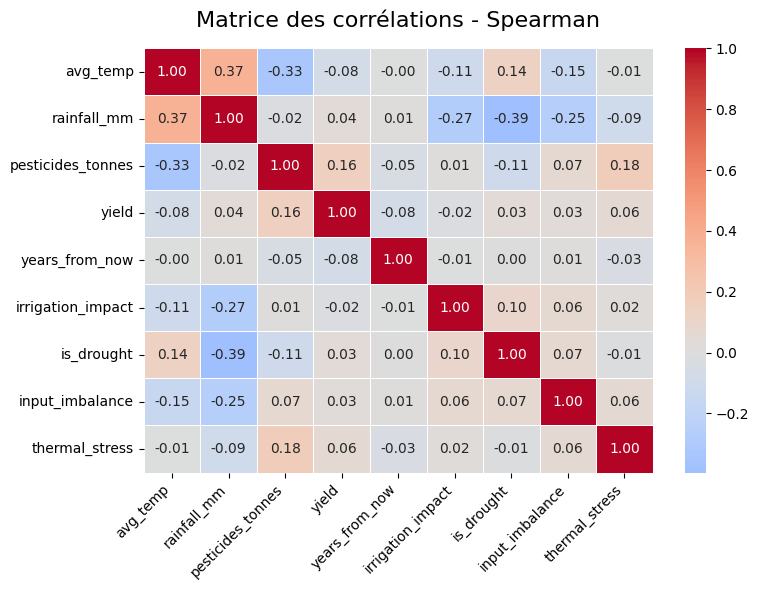

In [9]:
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5)
plt.title("Matrice des corrélations - Spearman", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../notebooks/graph/matrice_correlation_spearman_conso.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white")
plt.show()

### Sauvegarde de la dernière mise à jour

In [33]:
df = pd.read_csv("../data/processed/yield_df_final_conso_encoded_test.csv")

## Feature engineering sur le fichier consolidé
### Chargement du fichier

In [10]:
yield_df_final = pd.read_csv('../data/processed/yield_df_final.csv', index_col = 0)
yield_df_final_conso = yield_df_final.copy()

### Harmonisation des noms des variables

In [11]:
yield_df_final_conso['item'] = yield_df_final_conso['item'].replace({
    'Rice, paddy': 'Rice',
    'Soybeans': 'Soybean',
    'Maize': 'Maize',
    'Wheat': 'Wheat',
    'Barley': 'Barley'
})
yield_df_final_conso['item'].unique()

array(['Maize', 'Potatoes', 'Rice', 'Wheat', 'Sorghum', 'Soybean',
       'Cassava', 'Yams', 'Sweet potatoes', 'Plantains and others'],
      dtype=object)

### Ajout des nouvelles variables

In [12]:
# Flag de sécheresse (Binaire) 
yield_df_final_conso['is_drought'] = (yield_df_final_conso['rainfall_mm'] < 200).astype(float)

# Déséquilibre intrants/eau (Ecart log)
yield_df_final_conso['input_imbalance'] = np.abs(np.log1p(yield_df_final_conso['pesticides_tonnes']) - np.log1p(yield_df_final_conso['rainfall_mm']))

# Stress thermique simple 
yield_df_final_conso['thermal_stress'] = np.abs(yield_df_final_conso['avg_temp'] - 20)

# On fixe l'année de référence 2016 pour l'interface future.
year_ref = 2016

# On crée un score de maturité technologique
# Plus l'écart est grand, plus les semences et machines sont supposées performantes.
yield_df_final_conso['years_from_now'] = year_ref - yield_df_final_conso['year']



### Test séparation variables numériques et catégorielles

In [13]:
# On détermine quels sont nos variables catégorielles et nos variables quantitatives
yield_df_final_conso = yield_df_final_conso.drop(columns={"area","year"}).copy()
num_cols = yield_df_final_conso.select_dtypes(include='number').columns
cat_cols = yield_df_final_conso.select_dtypes(include='object').columns
print(num_cols)
print(cat_cols)

Index(['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'yield', 'is_drought',
       'input_imbalance', 'thermal_stress', 'years_from_now'],
      dtype='object')
Index(['region', 'item'], dtype='object')


### Corrélation

In [15]:
spearman_corr = yield_df_final_conso[num_cols].corr(numeric_only=True, method='spearman')
spearman_corr

,avg_temp,rainfall_mm,pesticides_tonnes,yield,is_drought,input_imbalance,thermal_stress,years_from_now
avg_temp,1.000000,0.369051,-0.328893,-0.077806,0.142590,-0.146340,-0.006201,-0.002120
rainfall_mm,0.369051,1.000000,-0.016414,0.038608,-0.394816,-0.253167,-0.093309,0.013579
pesticides_tonnes,-0.328893,-0.016414,1.000000,0.156642,-0.105981,0.065299,0.177527,-0.045174
yield,-0.077806,0.038608,0.156642,1.000000,0.032009,0.025228,0.057594,-0.075102
is_drought,0.142590,-0.394816,-0.105981,0.032009,1.000000,0.070479,-0.011864,0.004501
input_imbalance,-0.146340,-0.253167,0.065299,0.025228,0.070479,1.000000,0.062466,0.014067
thermal_stress,-0.006201,-0.093309,0.177527,0.057594,-0.011864,0.062466,1.000000,-0.029976
years_from_now,-0.002120,0.013579,-0.045174,-0.075102,0.004501,0.014067,-0.029976,1.000000


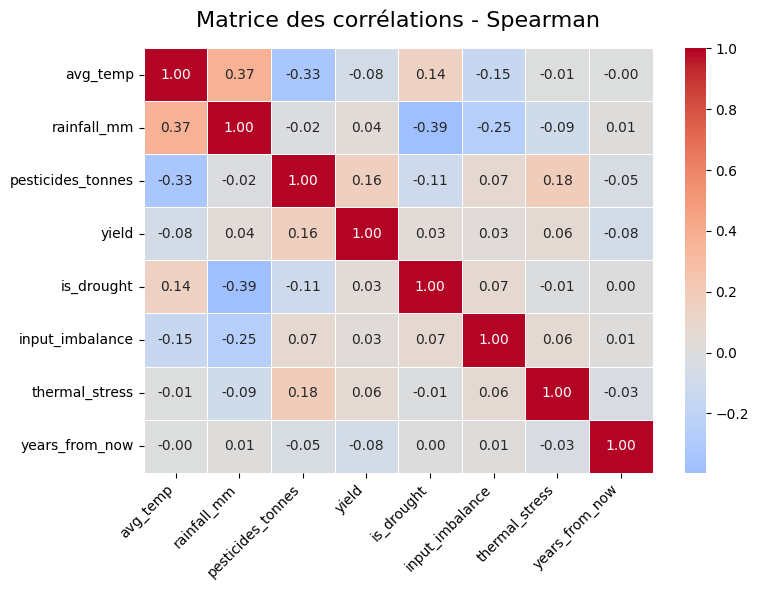

In [16]:
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5)
plt.title("Matrice des corrélations - Spearman", fontsize=16, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../notebooks/graph/matrice_correlation_spearman_conso.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white")
plt.show()

### Nombre de lignes et de colonnes avant et après

In [17]:
print(f"Nombre de lignes et de colonnes avant feature engineering {yield_df_final.shape}")
print("="*10)
print(f"Nombre de lignes et de colonnes après feature engineering {yield_df_final_conso.shape}")

Nombre de lignes et de colonnes avant feature engineering (29151, 8)
Nombre de lignes et de colonnes après feature engineering (29151, 10)


### Sauvegarde du fichier consolidé avec feature engineering

In [37]:
yield_df_final_conso.to_csv("../data/processed/yield_df_final_conso_encoded.csv")

# Feature engineering sur le fichier crop_yield de base
- Préparation si modélisation sur le fichier brut

In [18]:
# Avec index_co pour enlever la première colonne Unnamed 0
crop_yield = pd.read_csv("../data/processed/crop_yield.csv", index_col=0)

In [19]:
# Vérification globale
print(f"Nombre de lignes et de colonnes :\n{crop_yield.shape}\n")
print(f"Nombre de valeurs manquantes :\n{crop_yield.isnull().mean()}\n")
print(f"Nombre de doublons : {crop_yield.duplicated(keep=False).any()}")

Nombre de lignes et de colonnes :
(999769, 10)

Nombre de valeurs manquantes :
Region                    0.0
Soil_Type                 0.0
Crop                      0.0
Rainfall_mm               0.0
Temperature_Celsius       0.0
Fertilizer_Used           0.0
Irrigation_Used           0.0
Weather_Condition         0.0
Days_to_Harvest           0.0
Yield_tons_per_hectare    0.0
dtype: float64

Nombre de doublons : False


### Ajout de nouvelles variables

In [20]:
# Ratio climatique - indice d'irrigation critique
crop_yield['irrigation_impact'] = crop_yield['Irrigation_Used'].astype(int) / (crop_yield['Rainfall_mm'] + 1)
# Intensité du cycle
crop_yield['growth_intensity'] = crop_yield['Temperature_Celsius'] / (crop_yield['Days_to_Harvest'] + 1)

In [24]:
num_cols = crop_yield.select_dtypes(include='number').columns
cat_cols = crop_yield.select_dtypes(include=['object','bool']).columns
print(num_cols)
print(cat_cols)

Index(['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest',
       'Yield_tons_per_hectare', 'irrigation_impact', 'growth_intensity'],
      dtype='object')
Index(['Region', 'Soil_Type', 'Crop', 'Fertilizer_Used', 'Irrigation_Used',
       'Weather_Condition'],
      dtype='object')


### Corrélation

In [25]:
spearman_corr = crop_yield[num_cols].corr(numeric_only=True, method='spearman')
spearman_corr

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare,irrigation_impact,growth_intensity
Rainfall_mm,1.000000,-0.000372,-0.002680,0.769403,-0.267502,0.001926
Temperature_Celsius,-0.000372,1.000000,-0.000754,0.081018,-0.000231,0.722499
Days_to_Harvest,-0.002680,-0.000754,1.000000,-0.002409,-0.000012,-0.669067
Yield_tons_per_hectare,0.769403,0.081018,-0.002409,1.000000,0.109589,0.060566
irrigation_impact,-0.267502,-0.000231,-0.000012,0.109589,1.000000,0.000029
growth_intensity,0.001926,0.722499,-0.669067,0.060566,0.000029,1.000000


### La réalisation de l'encodage se fera automatiquement dans le pipeline